In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

In [2]:
plt.style.use("ggplot")

# 問題9.2

## (a)

In [3]:
df = pd.DataFrame(
    {
        "CAR":[1]*4 + [2]*4+ [3]*4+[4]*4,
        "AGE":[1, 2, 3, 4]*4,
        "y_d0":[65, 65, 52, 310, 98, 159, 175, 877, 41, 117, 137, 477, 11, 35, 39, 167],
        "n_d0":[317, 476, 486, 3259, 486, 1004, 1355, 7660, 223, 539, 697, 3442, 40, 148, 214, 1019],
        "y_d1":[2, 5, 4, 36, 7, 10, 22, 102, 5, 7, 16, 63, 0, 6, 8, 33],
        "n_d1":[20, 33, 40, 316, 31, 81, 122, 724, 18, 39, 68, 344, 3, 16, 25, 114]
        
    }
)

In [4]:
df

,CAR,AGE,y_d0,n_d0,y_d1,n_d1
0,1,1,65,317,2,20
1,1,2,65,476,5,33
2,1,3,52,486,4,40
3,1,4,310,3259,36,316
4,2,1,98,486,7,31
5,2,2,159,1004,10,81
6,2,3,175,1355,22,122
7,2,4,877,7660,102,724
8,3,1,41,223,5,18
9,3,2,117,539,7,39


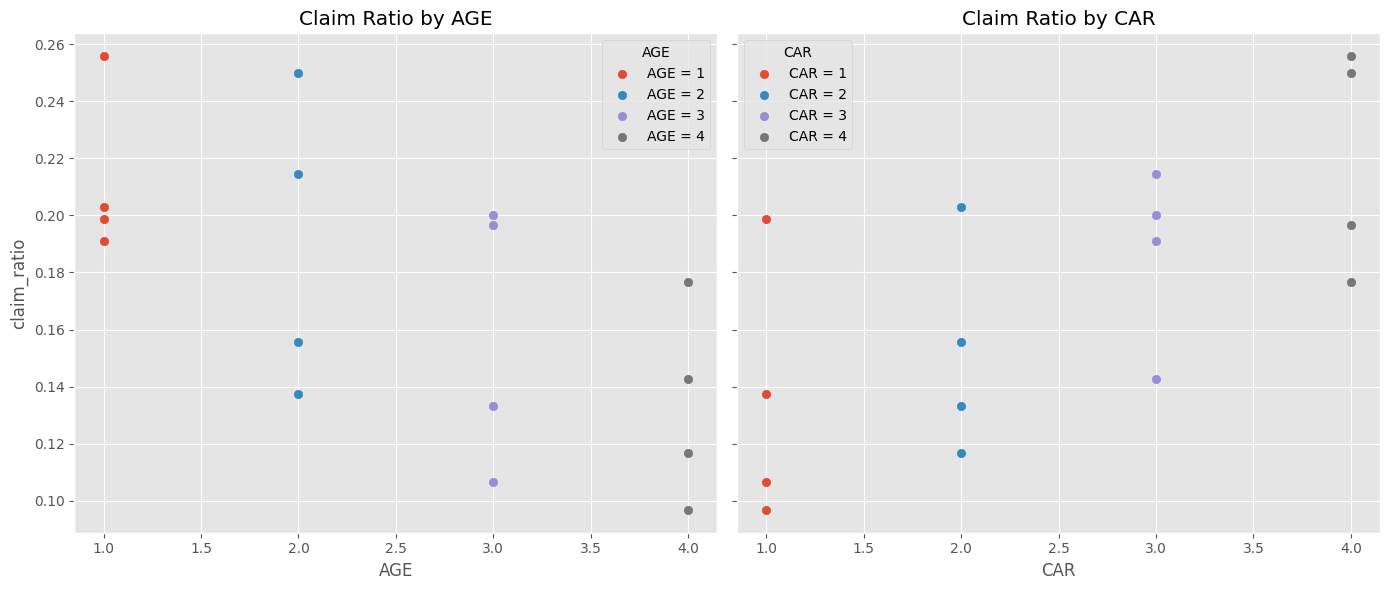

In [5]:
# 合計
df["n"] = df["n_d0"] + df["n_d1"]
df["y"] = df["y_d0"] + df["y_d1"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# AGEごとに請求率をプロット
for age, group in df.groupby("AGE"):
    group["ratio"] = group["y"] / group["n"]
    axes[0].scatter(group["AGE"], group["ratio"], marker='o', label=f"AGE = {age}")

axes[0].set_xlabel("AGE")
axes[0].set_ylabel("claim_ratio")
axes[0].set_title("Claim Ratio by AGE")
axes[0].legend(title="AGE")

# CARごとに
for car, group in df.groupby("CAR"):
    group["ratio"] = group["y"] / group["n"]
    axes[1].scatter(group["CAR"], group["ratio"], marker='o', label=f"CAR = {car}")

axes[1].set_xlabel("CAR")
axes[1].set_title("Claim Ratio by CAR")
axes[1].legend(title="CAR")
plt.tight_layout()
plt.savefig("test.png")
plt.show()

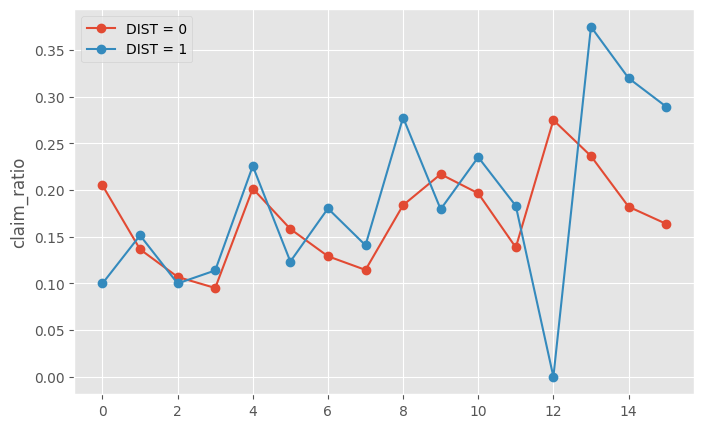

In [6]:
plt.figure(figsize = (8, 5))
plt.plot(df.index,df["y_d0"] / df["n_d0"], marker='o', label = "DIST = 0")
plt.plot(df.index,df["y_d1"] / df["n_d1"], marker='o', label = "DIST = 1")
plt.ylabel("claim_ratio")
plt.legend()
plt.savefig("DIST.png")
plt.show()

## (b)

In [7]:
# car_age_cols = [f"CAR_{i}" for i in range(2, 5)] + [f"AGE_{i}" for i in range(2, 5)]
car_age_cols = ["CAR", "AGE"]

# DIST=0 と DIST=1 のデータを作成
df_arrange = pd.concat([
    df[car_age_cols + ["y_d0", "n_d0"]]
        .rename(columns={"y_d0": "y", "n_d0": "n"})
        .assign(DIST=0),
    
    df[car_age_cols + ["y_d1", "n_d1"]]
        .rename(columns={"y_d1": "y", "n_d1": "n"})
        .assign(DIST=1)
]).reset_index(drop=True)

# CARとAGEをダミー変数に変換
df_dummies = pd.get_dummies(df_arrange, columns = ["CAR", "AGE"], dtype = int)

In [8]:
# 交互作用項の追加
for i in range(2, 5):
    df_dummies[f"CAR_{i}*DIST"] = df_dummies[f"CAR_{i}"] * df_dummies["DIST"]
    df_dummies[f"AGE_{i}*DIST"] = df_dummies[f"AGE_{i}"] * df_dummies["DIST"]
    for j in range(2, 5):
        df_dummies[f"AGE_{i}*CAR_{j}"] = df_dummies[f"AGE_{i}"]*df_dummies[f"CAR_{j}"]
        df_dummies[f"AGE_{i}*CAR_{j}*DIST"] = df_dummies[f"AGE_{i}"]*df_dummies[f"CAR_{j}"]*df_dummies["DIST"]

# カラムの並び替え
sort_cols = [
    'CAR_2', 'CAR_3', 'CAR_4', 
    'AGE_2', 'AGE_3', 'AGE_4', 'DIST',

    'AGE_2*DIST', 'AGE_3*DIST', 'AGE_4*DIST', 
    'CAR_2*DIST', 'CAR_3*DIST', 'CAR_4*DIST', 
    
    'AGE_2*CAR_2', 'AGE_2*CAR_3', 'AGE_2*CAR_4',
    'AGE_3*CAR_2', 'AGE_3*CAR_3', 'AGE_3*CAR_4',
    'AGE_4*CAR_2', 'AGE_4*CAR_3', 'AGE_4*CAR_4',
    
    'AGE_2*CAR_2*DIST', 'AGE_2*CAR_3*DIST', 'AGE_2*CAR_4*DIST',
    'AGE_3*CAR_2*DIST', 'AGE_3*CAR_3*DIST', 'AGE_3*CAR_4*DIST',
    'AGE_4*CAR_2*DIST', 'AGE_4*CAR_3*DIST', 'AGE_4*CAR_4*DIST',
    'y', 'n'
]
df_dummies = df_dummies[sort_cols]

In [9]:
df_dummies.head()

,CAR_2,CAR_3,CAR_4,AGE_2,AGE_3,AGE_4,DIST,AGE_2*DIST,AGE_3*DIST,AGE_4*DIST,...,AGE_2*CAR_3*DIST,AGE_2*CAR_4*DIST,AGE_3*CAR_2*DIST,AGE_3*CAR_3*DIST,AGE_3*CAR_4*DIST,AGE_4*CAR_2*DIST,AGE_4*CAR_3*DIST,AGE_4*CAR_4*DIST,y,n
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,65,317
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,65,476
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,52,486
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,310,3259
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,98,486


In [10]:
# Newton-Raphson法
def NewtonRaphson(n_iters, beta, df, expvar):

    df = df.copy()
    
    # 使用変数
    X = np.hstack([np.ones(len(df)).reshape(len(df), 1), df[expvar].values])
    
    y = df["y"].values
    n = df["n"].values

    # ポアソン回帰モデルにおける期待値
    def _mu(X, beta, n):
        return n*np.exp(np.sum(X*beta, axis = 1))
        
    # Newton-Raphsonによる反復更新
    for _ in range(n_iters):

        # スコアUの計算
        mu_ = _mu(X, beta, n)
        U = (X*(y - mu_).reshape(len(df), 1)).sum(axis = 0)
    
        # 情報行列Jの計算
        list_J = []
        for j in range(X.shape[1]):
            X_j = X[:, j]
            list_J_jk = []
            for k in range(X.shape[1]):
                X_k = X[:, k]
                list_J_jk.append(np.sum(mu_*X_j*X_k))
            list_J.append(list_J_jk)
        J = np.array(list_J)
    
        # 係数の更新
        beta = beta + np.linalg.inv(J)@U

    # 標準誤差の推定
    std_error = np.sqrt(np.diag(np.linalg.inv(J)))
    
    return beta, J, std_error

In [19]:
# 使用する説明変数
expvar = [v for v in df_dummies.columns if v not in ["y", "n"]]

# 係数の初期値
beta = np.zeros(len(expvar)+1)

# 反復回数
n_iters = 30

# Newton-Raphson法による推定
beta_b, J_b, std_error = NewtonRaphson(n_iters, beta, df_dummies, expvar)

In [21]:
# 係数推定値
df_coef_b = pd.DataFrame({"ポアソン回帰の係数推定値": beta_b, "標準誤差":std_error}, index = ["定数"] + expvar)
df_coef_b

,ポアソン回帰の係数推定値,標準誤差
定数,-1.584515,1.240347e-01
CAR_2,-0.016727,1.599647e-01
CAR_3,-0.109085,1.994364e-01
CAR_4,0.293530,3.260272e-01
AGE_2,-0.406516,1.754116e-01
AGE_3,-0.650450,1.860521e-01
AGE_4,-0.768089,1.364200e-01
DIST,-0.718071,7.179029e-01
AGE_2*DIST,0.822032,8.548504e-01
AGE_3*DIST,0.650450,8.857852e-01


## (c)

In [14]:

# 使用する説明変数
expvar = ["CAR", "AGE", "DIST"]

# 係数の初期値
beta = np.zeros(len(expvar)+1)

# 反復回数
n_iters = 100

# Newton-Raphson法による推定
beta_c, J_c, std_error = NewtonRaphson(n_iters, beta, df_arrange, expvar)

In [15]:
# 係数推定値
pd.DataFrame({"ポアソン回帰の係数推定値": beta_c, "標準誤差":std_error}, index = ["定数"] + expvar)

,ポアソン回帰の係数推定値,標準誤差
定数,-1.852532,0.079903
CAR,0.197769,0.020803
AGE,-0.176740,0.018489
DIST,0.218646,0.058528


## (b)の2次の交互作用項までの場合

In [30]:
# 使用する説明変数
expvar = ['CAR_2',
 'CAR_3',
 'CAR_4',
 'AGE_2',
 'AGE_3',
 'AGE_4',
 'DIST',
 'AGE_2*DIST',
 'AGE_3*DIST',
 'AGE_4*DIST',
 'CAR_2*DIST',
 'CAR_3*DIST',
 'CAR_4*DIST',
 'AGE_2*CAR_2',
 'AGE_2*CAR_3',
 'AGE_2*CAR_4',
 'AGE_3*CAR_2',
 'AGE_3*CAR_3',
 'AGE_3*CAR_4',
 'AGE_4*CAR_2',
 'AGE_4*CAR_3',
 'AGE_4*CAR_4'
]

# 係数の初期値
beta = np.zeros(len(expvar)+1)

# 反復回数
n_iters = 30

# Newton-Raphson法による推定
beta_b2, J_b, std_error_b2 = NewtonRaphson(n_iters, beta, df_dummies, expvar)

In [31]:

df_coef_b2 = pd.DataFrame({"ポアソン回帰の係数推定値": beta_b2, "標準誤差":std_error_b2}, index = ["定数"] + expvar)

In [39]:
df_coef_b_table = pd.merge(df_coef_b, df_coef_b2, left_index = True, right_index = True, how = "outer", suffixes=('_with_3rd_inter_term', '_without_3rd_inter_term'))
df_coef_b_table.reindex(index = df_coef_b.index)

,ポアソン回帰の係数推定値_with_3rd_inter_term,標準誤差_with_3rd_inter_term,ポアソン回帰の係数推定値_without_3rd_inter_term,標準誤差_without_3rd_inter_term
定数,-1.584515,1.240347e-01,-1.608286,0.123205
CAR_2,-0.016727,1.599647e-01,0.016862,0.156663
CAR_3,-0.109085,1.994364e-01,-0.047719,0.191942
CAR_4,0.293530,3.260272e-01,0.220929,0.325960
AGE_2,-0.406516,1.754116e-01,-0.364350,0.171865
AGE_3,-0.650450,1.860521e-01,-0.642968,0.182222
AGE_4,-0.768089,1.364200e-01,-0.740581,0.134666
DIST,-0.718071,7.179029e-01,-0.127023,0.302763
AGE_2*DIST,0.822032,8.548504e-01,-0.063619,0.339671
AGE_3*DIST,0.650450,8.857852e-01,0.266343,0.315739


# 演習問題9.3

In [5]:
df = pd.DataFrame(
    {
        "小":[25, 6],
        "中":[8, 18],
        "大":[5, 11]
    },
    index = ["プラセボ", "ワクチン"]
)

In [6]:
df

,小,中,大
プラセボ,25,8,5
ワクチン,6,18,11


## (a)

### カイ2乗検定

In [7]:
df.sum()

小    31
中    26
大    16
dtype: int64

In [8]:
df.sum(axis = 1)

プラセボ    38
ワクチン    35
dtype: int64

In [9]:
# 各セルにおける観測度数
e = (df.sum(axis = 1).values.reshape(2, 1) @ df.sum().values.reshape(1, 3)) / df.values.sum()

# カイ2乗検定統計量
X = ((df.values - e)**2 / e).sum()

# 自由度の計算
f = (df.shape[0] - 1) * (df.shape[1] - 1)

# 有意水準
alpha = 0.05

# 上側 alpha/2 * 100 %点
quantile = chi2.ppf(1 - (alpha / 2), f)

In [10]:
# 検定
print(f"自由度 : {f}")
print(f"カイ2乗検定統計量 : {X}")
print(f"上側2.5%点 : {quantile}")
if X < quantile:
    print(f"有意水準{alpha*100}% で 帰無仮説 p_jk = p_j * p_k を棄却できない")
else:
    print(f"有意水準{int(alpha*100)}%で 独立性の帰無仮説H_0 : p_jk = p_j・ * p_・k を棄却できる")

自由度 : 2
カイ2乗検定統計量 : 17.647832398925356
上側2.5%点 : 7.377758908227871
有意水準5%で 独立性の帰無仮説H_0 : p_jk = p_j・ * p_・k を棄却できる


### 対数線形モデル
* プラセボかつ反応 = 小を基準カテゴリーとみなした

In [25]:
X = np.array(
    [
        [1, 0, 0, 0],
        [1, 0, 1, 0],
        [1, 0, 0, 1],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 0, 1]
    ]
)
y = df.values.reshape(-1)

# 最小二乗法による推定
beta1 = np.linalg.inv(X.T@X)@X.T@y

In [19]:
mu1 = df.values.sum() * 

array([16. , -1. , -2.5, -7.5])

In [30]:
beta1

array([16. , -1. , -2.5, -7.5])